In [61]:
from pathlib import Path

import pandas as pd
from Satellite import Satellite
from Point import Point
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

RANGE=28000
MIN_NEIGHBOR=0
MAX_NEIGHBOR=0

def load_data(filepath: str | Path, separator: str = ",", header: int | None = None) -> pd.DataFrame:
    """Load raw data from a CSV file.

    Args:
        filepath: Path to the CSV file (str or Path object).
        separator: Column delimiter used in the CSV file. Defaults to ','.
        header: Row number to use as column names.
                None means no header row. Defaults to None.

    Returns:
        Raw DataFrame loaded from the CSV file.

    Raises:
        FileNotFoundError: If the file does not exist at the given path.
        ValueError: If the file extension is not '.csv'.
    """
    filepath = Path(filepath)

    if not filepath.exists():
        raise FileNotFoundError(f"File not found: '{filepath}'")

    if filepath.suffix.lower() != ".csv":
        raise ValueError(
            f"Expected a '.csv' file, got '{filepath.suffix}' instead."
        )

    return pd.read_csv(filepath, sep=separator, header=header)

def struct_data(df: pd.DataFrame) -> list[Satellite]:

    # Create columns label
    df.columns = [f"t{i}" for i in range(len(df.columns))]

    satellites = []

    import time
    start = time.perf_counter()   

    # Satellite coordinate data processing
    for i in range(0, len(df), 3):
        coords = df.iloc[i:i+3].values
        satellite = Satellite(f"SAT-{int(i/3):03d}")

        for j in range(coords.shape[1]):
            satellite.add_instant(Point(coords[0, j], coords[1, j], coords[2, j]))

        satellites.append(satellite)

    # Satellite neighbors processing
    for index, sat in enumerate(satellites):
        for other_sat in satellites[index+1:]:
            for i in range(len(sat.list_coordinates)):
                in_range = sat.list_coordinates[i].point.in_range( other_sat.list_coordinates[i].point, RANGE)
                if in_range:
                    sat.list_coordinates[i].neighbors.append(other_sat)
                    other_sat.list_coordinates[i].neighbors.append(sat)
    end = time.perf_counter()

    print(len(satellites))
    print(f"Temps écoulé : {end - start} secondes")

    return satellites

def show_data(satellites: list[Satellite], number: int) -> None:
    plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")

    for sat in satellites[:number]:
        xs = np.array([instant.point.x for instant in sat.list_coordinates])
        ys = np.array([instant.point.y for instant in sat.list_coordinates])
        zs = np.array([instant.point.z for instant in sat.list_coordinates])

        axes.plot(xs, ys, zs, label=f"Sat {sat.name}")

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title("Trajectoires des Satellites")
    plt.show()


def show_instant_nodes(satellites: list[Satellite], instant: int) -> None:
    plt.show()
    plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")

    # Create Nodes
    for sat in satellites:
        point = sat.list_coordinates[instant].point    
        axes.scatter(
            xs=point.x,
            ys=point.y,
            zs=point.z,
            s=50,
            c='blue',
            label='Satellites')

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title(f"t{instant} des Satellites")
    # plt.legend()
    plt.show()

def show_instant_nodes_edges(satellites: list[Satellite], instant: int) -> None:
    plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")

    # Create Nodes and edges
    for sat in satellites:
        # Nodes
        point = sat.list_coordinates[instant].point    
        axes.scatter(
            xs=point.x,
            ys=point.y,
            zs=point.z,
            s=50,
            #c='blue',
            label='Satellites')

        # Edges
        for neighbor in sat.list_coordinates[instant].neighbors:
            neighbor_point = neighbor.list_coordinates[instant].point
            axes.plot(
                [point.x, neighbor_point.x],
                [point.y, neighbor_point.y],
                [point.z, neighbor_point.z],
                'r-',
                alpha=0.1,
                linewidth=1
            )


    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title(f"t{instant} des Satellites")
    # plt.legend()
    plt.show()

def show_instant_nodes_neighbor(satellites: list[Satellite], instant: int, label: bool = True) -> None:
    fig = plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")


    densities = np.array([
        len(sat.list_coordinates[instant].neighbors)
        for sat in satellites
    ])

    norm = plt.Normalize(vmin=densities.min(), vmax=densities.max())
    colormap = cm.viridis

    # Create Nodes and edges
    for sat, density in zip(satellites, densities):
        # Nodes
        color = (255/255, 0/255, 0/255, 1.0) if density == 0 else colormap(norm(density)) 
        point = sat.list_coordinates[instant].point
        axes.scatter(
            xs=point.x,
            ys=point.y,
            zs=point.z,
            s=50,
            color=color,
            label='Satellites')
        
        if label:
            axes.text(
                x=point.x,
                y=point.y,
                z=point.z,
                s=sat.name,
                fontsize=8,
                color='black',
                ha='right',
                va='bottom')

        # Edges
        for neighbor in sat.list_coordinates[instant].neighbors:
            neighbor_point = neighbor.list_coordinates[instant].point
            axes.plot(
                [point.x, neighbor_point.x],
                [point.y, neighbor_point.y],
                [point.z, neighbor_point.z],
                'r-',
                alpha=0.1,
                linewidth=1
            )

    scalar_mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
    scalar_mappable.set_array(densities)
    fig.colorbar(scalar_mappable, ax=axes, label="Nombre de voisins", shrink=0.5)

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title(f"t{instant} des Satellites")
    # plt.legend()
    plt.show()


In [62]:
data = load_data("./traces.csv")
print(data[:10])
satellites = struct_data(data)

           0             1             2             3             4     \
0 -4.850747e+05 -4.937755e+05 -5.024536e+05 -5.111086e+05 -5.197401e+05   
1 -7.066530e+05 -7.201117e+05 -7.335372e+05 -7.469290e+05 -7.602864e+05   
2 -2.026363e+06 -2.019625e+06 -2.012795e+06 -2.005871e+06 -1.998855e+06   
3 -4.167305e+05 -4.253905e+05 -4.340304e+05 -4.426496e+05 -4.512477e+05   
4 -7.114496e+05 -7.251144e+05 -7.387446e+05 -7.523398e+05 -7.658991e+05   
5 -2.013985e+06 -2.007244e+06 -2.000408e+06 -1.993476e+06 -1.986450e+06   
6 -4.839084e+05 -4.922692e+05 -5.006077e+05 -5.089237e+05 -5.172168e+05   
7 -7.608448e+05 -7.742544e+05 -7.876291e+05 -8.009682e+05 -8.142713e+05   
8 -2.023770e+06 -2.016739e+06 -2.009618e+06 -2.002406e+06 -1.995103e+06   
9 -3.527034e+05 -3.616050e+05 -3.704891e+05 -3.793552e+05 -3.882029e+05   

           5             6             7             8             9     ...  \
0 -5.283476e+05 -5.369309e+05 -5.454894e+05 -5.540229e+05 -5.625310e+05  ...   
1 -7.736088e+0

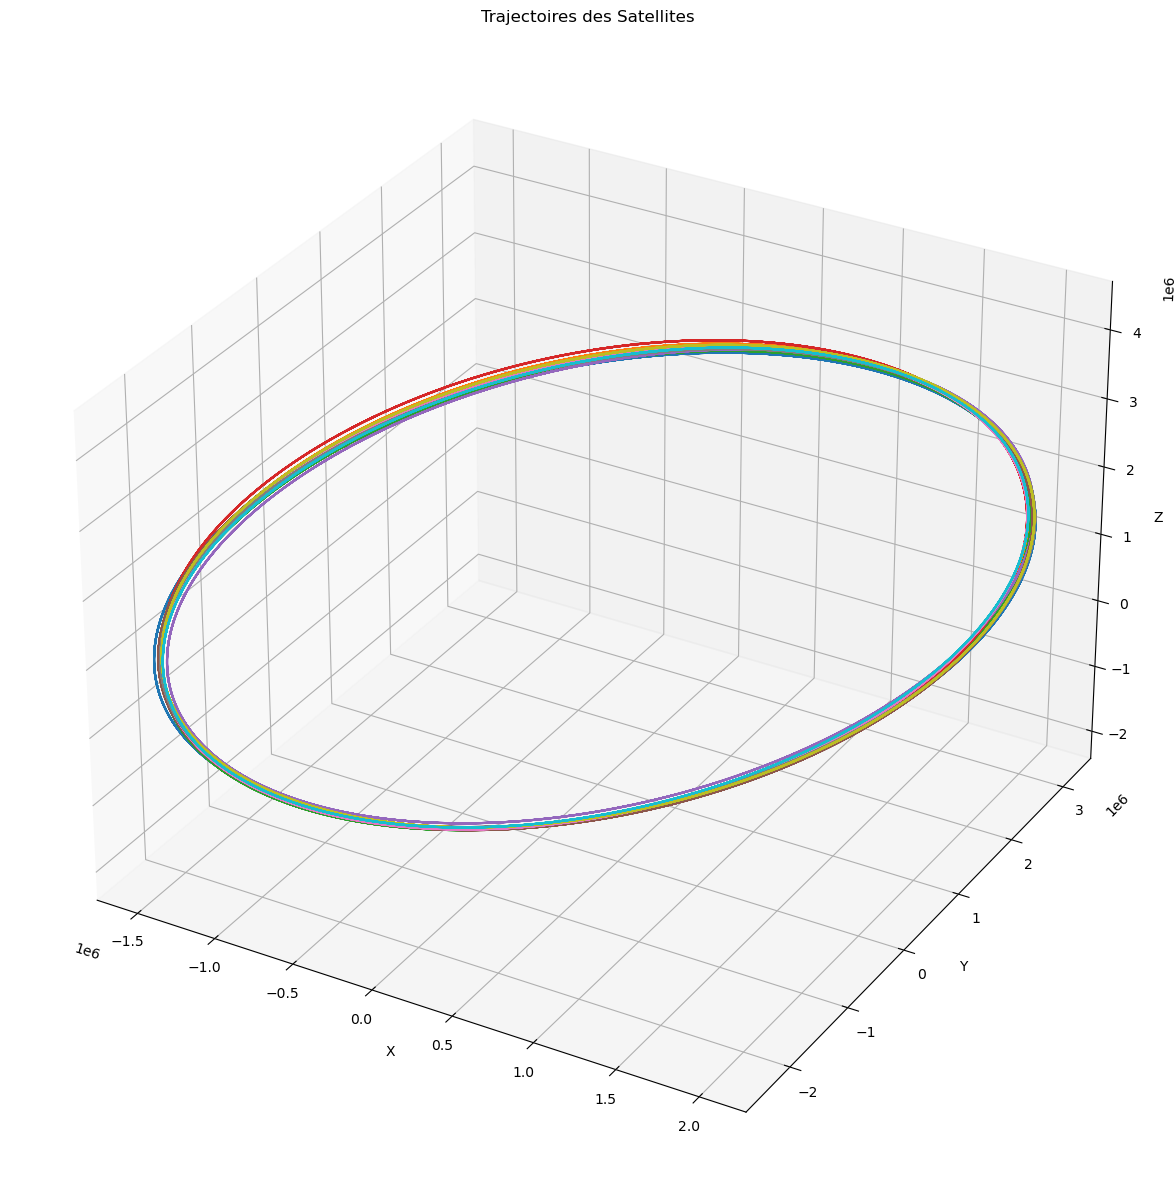

In [63]:
show_data(satellites, 10)

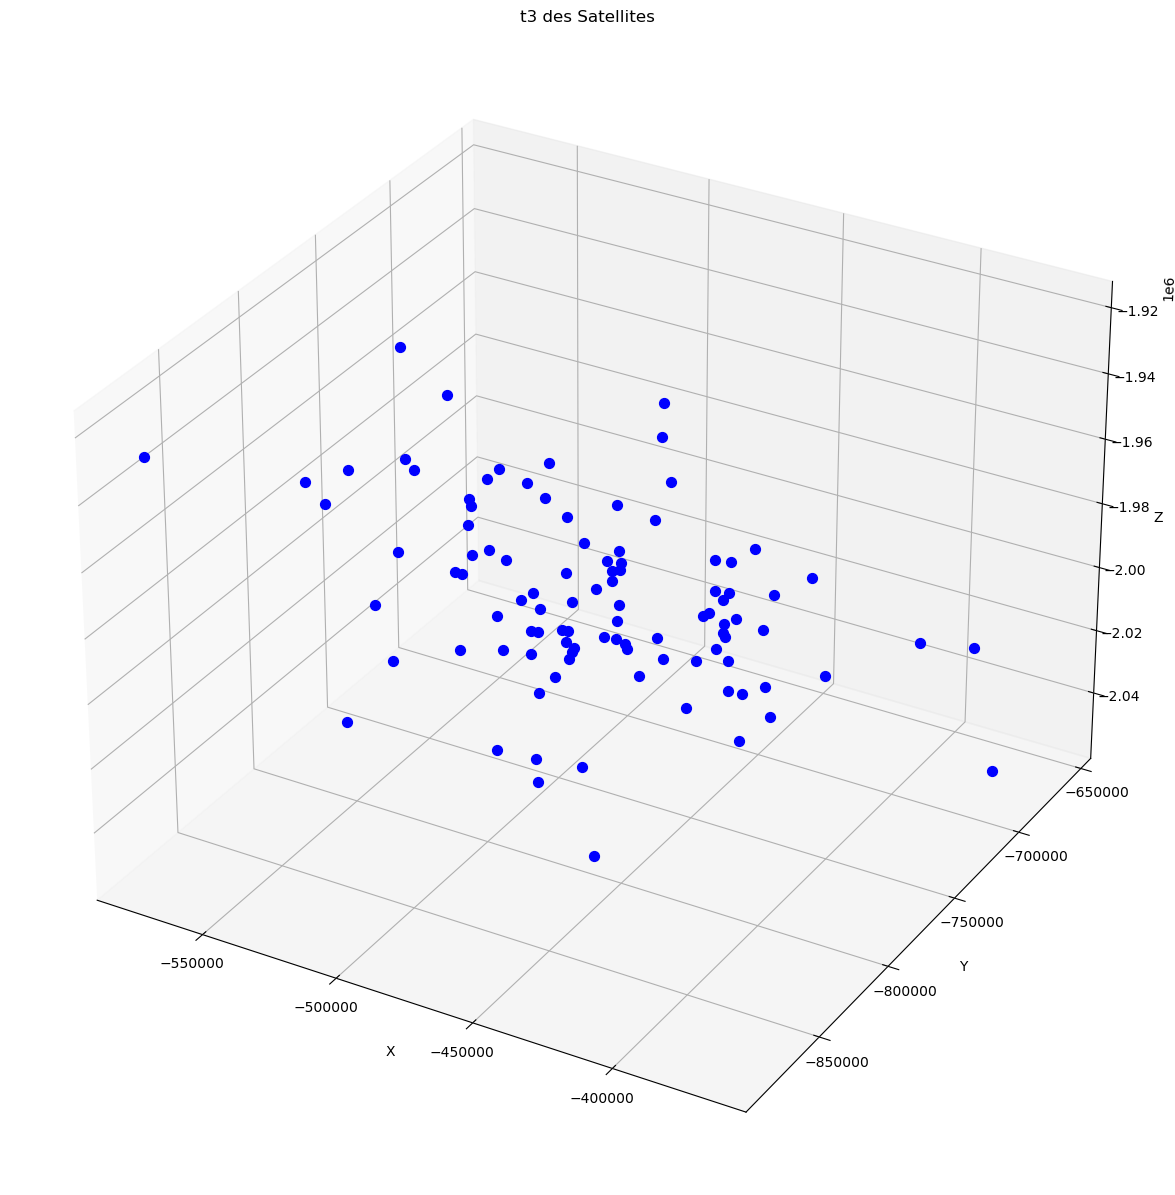

In [64]:
show_instant_nodes(satellites, 3)

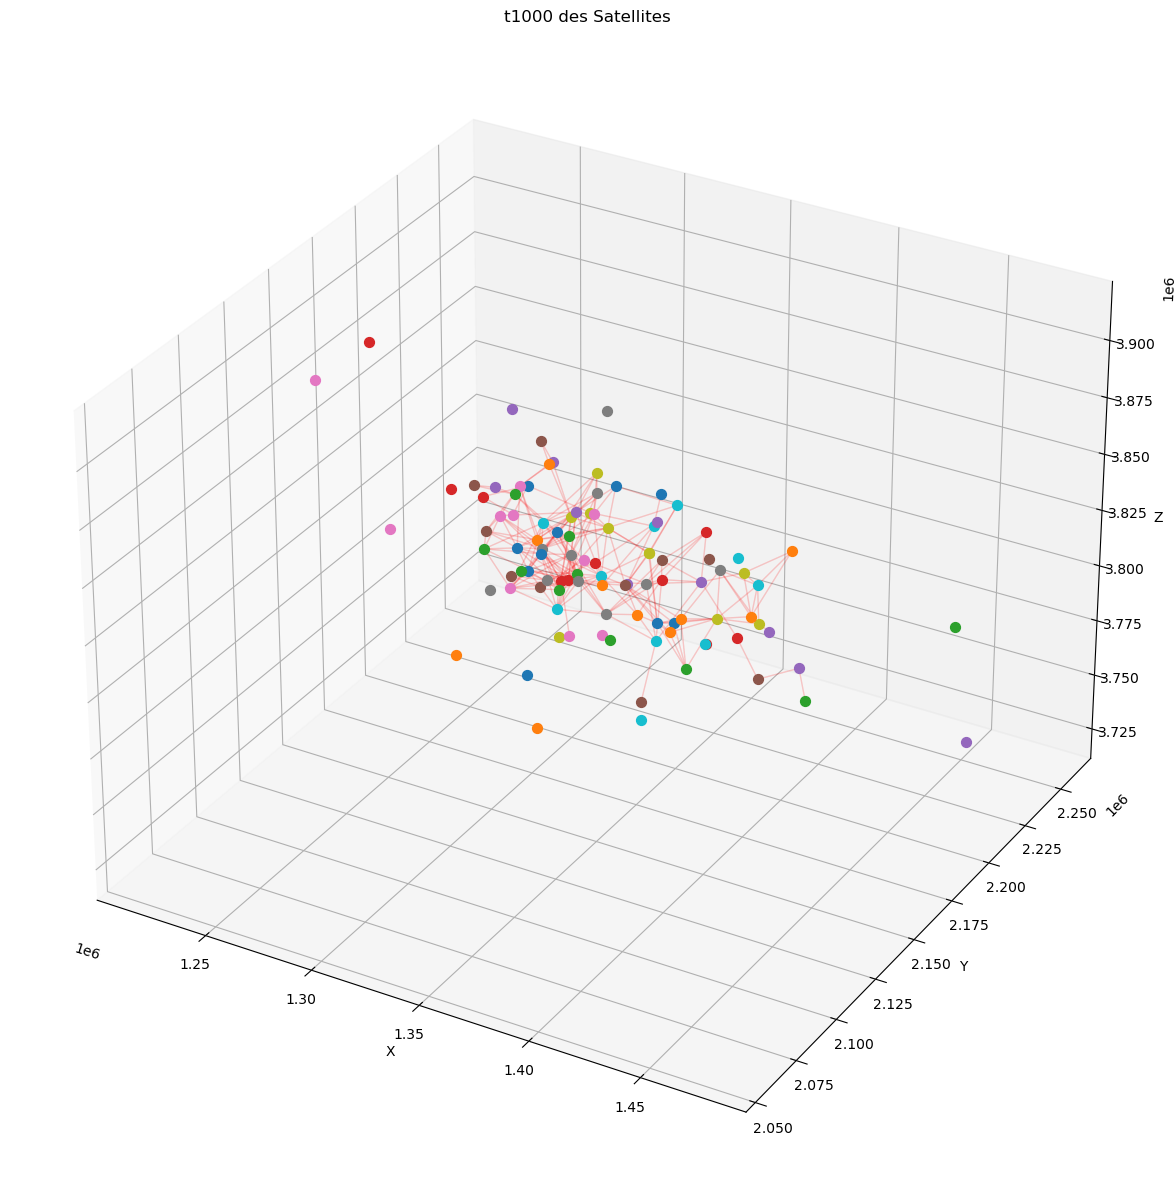

In [65]:
show_instant_nodes_edges(satellites, 1000)

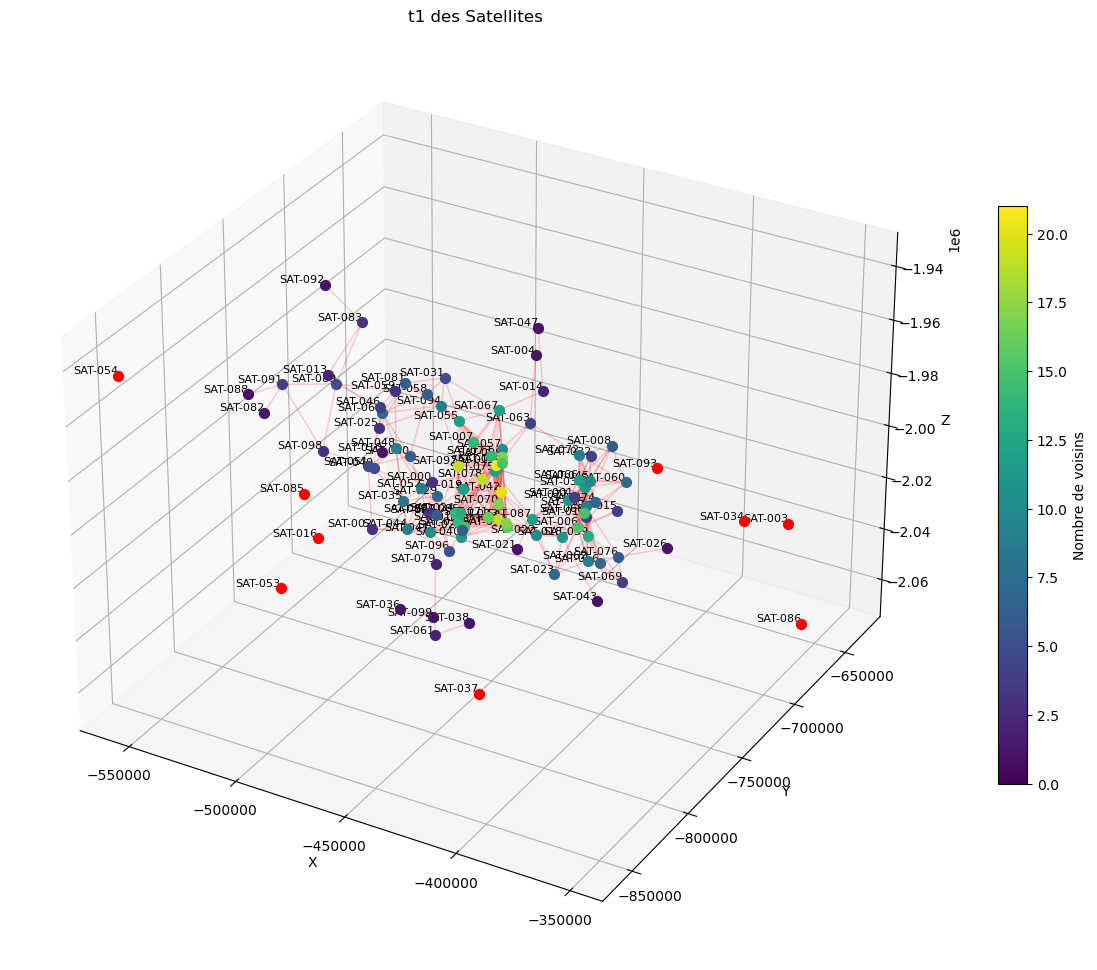

In [68]:
show_instant_nodes_neighbor(satellites=satellites, instant=1, label=True)


In [28]:
from NetworkSimulation import NetworkSimulation, PDU, FloodingRouter

list_satellites = satellites 
nb_instants = len(satellites[0].list_coordinates)

# Tuple description
# (Instant index of PDU, PDU)
example_scenario = [
    (0, PDU(1, list_satellites[0].name, list_satellites[-1].name)),
    (1, PDU(2, list_satellites[0].name, list_satellites[-1].name)),
    (2, PDU(3, list_satellites[0].name, list_satellites[-1].name)),
]

simulation = NetworkSimulation(satellites, FloodingRouter, example_scenario)
print(f"At time {simulation.current_index}, does {list_satellites[0].name} have messages to send ? {simulation.routers[list_satellites[0].name].any_messages_to_send()}")
simulation.next()
print(f"At time {simulation.current_index}, does {list_satellites[0].name} have messages to send ? {simulation.routers[list_satellites[0].name].any_messages_to_send()}")

def messages_received_of_dest():
    return simulation.routers[list_satellites[-1].name].pdus_where_this_router_is_the_destination

while len(messages_received_of_dest()) < len(example_scenario) and simulation.current_index < nb_instants:
    simulation.next()

print(f"At time {simulation.current_index}, {list_satellites[-1].name} has fully received {len(messages_received_of_dest())} messages")

if messages_received_of_dest():
    print("Traces of each messages")
    for pdu in messages_received_of_dest():
        print(pdu)

At time 0, does SAT-000 have messages to send ? False
At time 1, does SAT-000 have messages to send ? True
At time 5, SAT-297 has fully received 3 messages
Traces of each messages
PDU #1
  From : SAT-000
  To   : SAT-297
  Path : SAT-000 -> SAT-006 -> SAT-297
PDU #2
  From : SAT-000
  To   : SAT-297
  Path : SAT-000 -> SAT-006 -> SAT-297
PDU #3
  From : SAT-000
  To   : SAT-297
  Path : SAT-000 -> SAT-006 -> SAT-297
